# 01 · The forward process, schedules & the "nice property"

The forward process adds a little Gaussian noise at each step $t$:

$$q(x_t \mid x_{t-1}) = \mathcal{N}\!\big(x_t;\ \sqrt{1-\beta_t}\,x_{t-1},\ \beta_t I\big)$$

The sequence $\beta_1, \dots, \beta_T$ is the **noise schedule**. Define
$\alpha_t = 1-\beta_t$ and the cumulative product
$\bar\alpha_t = \prod_{s\le t}\alpha_s$. The quantity $\bar\alpha_t$ is *how much of
the original signal survives* to step $t$.

In [1]:
import torch
import matplotlib.pyplot as plt

from nanodiffusion.utils import set_seed, scatter_2d
from nanodiffusion.data import toy2d
from nanodiffusion.schedules import NoiseSchedule, linear_beta_schedule, cosine_beta_schedule
from nanodiffusion.forward import add_noise

set_seed(0)

## Two schedules: linear vs cosine

The original DDPM used a **linear** $\beta$ schedule. The "improved DDPM" paper
introduced a **cosine** schedule that destroys the signal more gently early on,
which helps sample quality. Let's compare what happens to $\bar\alpha_t$.

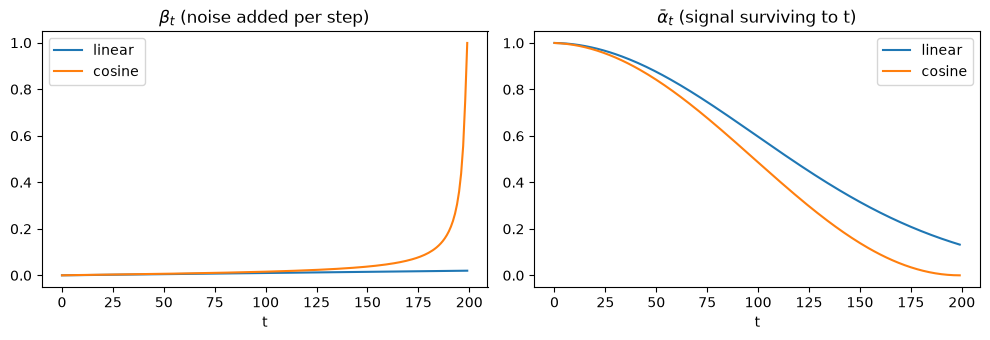

In [2]:
T = 200
lin = NoiseSchedule(linear_beta_schedule(T))
cos = NoiseSchedule(cosine_beta_schedule(T))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.5))
a1.plot(lin.betas, label="linear"); a1.plot(cos.betas, label="cosine")
a1.set_title(r"$\beta_t$ (noise added per step)"); a1.set_xlabel("t"); a1.legend()
a2.plot(lin.alpha_bars, label="linear"); a2.plot(cos.alpha_bars, label="cosine")
a2.set_title(r"$\bar\alpha_t$ (signal surviving to t)"); a2.set_xlabel("t"); a2.legend()
plt.tight_layout(); plt.show()

## The "nice property" (why diffusion is trainable)

Because each step adds Gaussian noise, and sums of Gaussians are Gaussian, we can
skip straight from $x_0$ to $x_t$ **in one shot** — no need to simulate all $t$
steps. Using the reparameterization trick:

$$\boxed{\,x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,\quad \varepsilon\sim\mathcal N(0, I)\,}$$

This single equation *is* `nanodiffusion.forward.add_noise`. In code it's literally:

```python
x_t = sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * noise
```

This is what lets us train on a *random* $t$ each step — the key to making
diffusion practical.

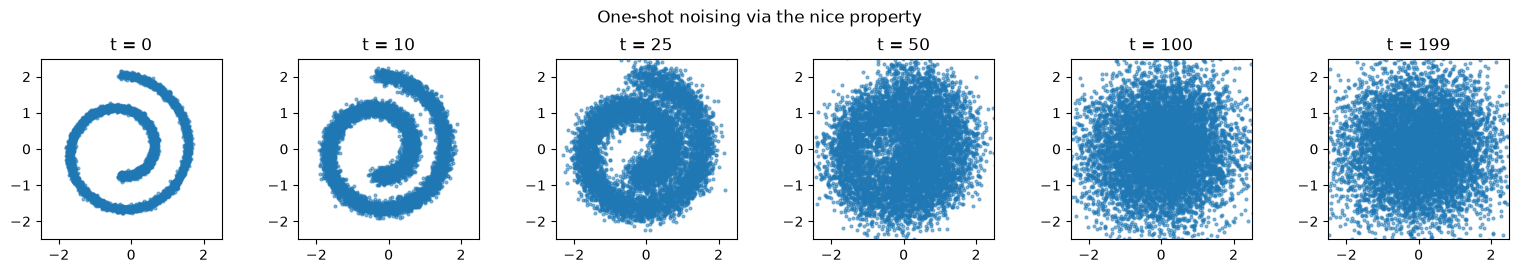

In [3]:
data = toy2d("swiss_roll", 8000)
schedule = NoiseSchedule.make("cosine", T)

ts = [0, 10, 25, 50, 100, 199]
fig, axes = plt.subplots(1, len(ts), figsize=(2.6 * len(ts), 2.6))
for ax, t in zip(axes, ts):
    x_t, eps = add_noise(data, torch.full((data.shape[0],), t), schedule)
    scatter_2d(ax, x_t, f"t = {t}")
plt.suptitle("One-shot noising via the nice property")
plt.tight_layout(); plt.show()

## Sanity checks

Two cheap asserts catch the classic bugs. These are exactly the kind of checks
worth keeping around — they fail loudly if a schedule or broadcast is wrong.

In [4]:
# 1) alpha_bar must be monotonically non-increasing (signal only decays).
assert torch.all(schedule.alpha_bars[:-1] >= schedule.alpha_bars[1:])

# 2) At t=T the data should be ~pure unit-variance noise (signal ~gone).
x_T, _ = add_noise(data, torch.full((data.shape[0],), T - 1), schedule)
print(f"alpha_bar_T = {schedule.alpha_bars[-1]:.4f}  (want ~0)")
print(f"std(x_T)    = {x_T.std().item():.4f}  (want ~1)")
assert schedule.alpha_bars[-1] < 0.05
assert abs(x_T.std().item() - 1.0) < 0.15
print("forward process looks correct ✔")

alpha_bar_T = 0.0000  (want ~0)
std(x_T)    = 1.0014  (want ~1)
forward process looks correct ✔


That's the forward process. Next: teach a network to *undo* it.
This code now lives in `nanodiffusion/schedules.py` and `nanodiffusion/forward.py`.